In [1]:
import getpass, logging
import arcgis.ai
from arcgis.ai import analyze_image, AIUtilsResponse, AIUtilsException
from arcgis.gis import GIS
from arcgis.features import FeatureLayer

logging.getLogger().setLevel(logging.CRITICAL)

In [2]:
print(arcgis.__version__) # 2.4.3 minimum

2.4.3


In [3]:
username = input("ArcGIS Online username: ")
password = getpass.getpass("ArcGIS Online password: ")
gis = GIS("https://www.arcgis.com", username, password, verify_cert=False)
print(f"Signed in as: {gis.users.me.username} ({gis.properties.portalName})")

ArcGIS Online username:  plouis_esrifrance
ArcGIS Online password:  ········


Signed in as: plouis_esrifrance (ArcGIS Online)


In [6]:
item = gis.content.get("a7856e2dee3949478beb489646aabbc6") #mettre la couche d'entités hébergée de votre choix, contenant des pj hébergées sur AGOL

<Item title:"Belfort  - DB2 - Formulaire de collecte des évènements sur la voie publique" type:Feature Layer Collection owner:plouis_esrifrance>
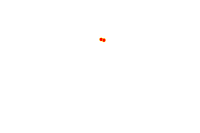

In [8]:
cloned_items = gis.content.clone_items([item])
cloned_item = cloned_items[0]
cloned_item.sharing.sharing_level = 'EVERYONE'
cloned_layer = cloned_item.layers[0]
cloned_item

In [9]:
new_field = {
    "name": "description_photo",
    "type": "esriFieldTypeString",
    "alias": "Description de la photo",
    "length": 1000
}

cloned_layer.manager.add_to_definition({
    "fields": [new_field]
})

{'success': True}

In [10]:
features = cloned_layer.query(where="1=1", out_fields="*", return_attachments=True)

In [11]:
updates = []

for feature in features.features:
    oid = feature.attributes[cloned_layer.properties.objectIdField]

    attachments = cloned_layer.attachments.get_list(oid)

    if not attachments:
        continue

    # on prend la première image (tu peux adapter)
    att = attachments[0]
    att_id = att["id"]

    image_url = f"{cloned_layer.url}/{oid}/attachments/{att_id}"

    response = analyze_image(
        image=image_url,
        prompt="Décris l'image en 1000 caractères maximum. Ce qui nous intéresse sont la description des événements sur la voie publique",
        to_language="fr",
        gis=gis
    )

    if isinstance(response, AIUtilsResponse):
        description = response.results[0].value if response.results else None
    else:
        description = None

    feature.attributes["description_photo"] = description
    updates.append(feature)
    print (f"entité {oid} traîtée")

entité 1 traîtée
entité 2 traîtée
entité 3 traîtée
entité 4 traîtée
entité 5 traîtée
entité 6 traîtée
entité 7 traîtée
entité 8 traîtée
entité 9 traîtée
entité 10 traîtée
entité 11 traîtée
entité 12 traîtée
entité 13 traîtée
entité 16 traîtée
entité 26 traîtée


In [12]:
cloned_layer.edit_features(updates=updates)

{'addResults': [],
 'updateResults': [{'objectId': 1,
   'uniqueId': 1,
   'globalId': '51f51da0-b948-4a69-9333-ea6e3a173a76',
   'success': True},
  {'objectId': 2,
   'uniqueId': 2,
   'globalId': 'ffc93946-8c73-4d1d-a97f-e008f888bbff',
   'success': True},
  {'objectId': 3,
   'uniqueId': 3,
   'globalId': 'c5d93a8a-7de1-46a6-aa17-a8331f3b25ea',
   'success': True},
  {'objectId': 4,
   'uniqueId': 4,
   'globalId': 'd4b328ce-99b8-400a-b7d7-2c60e98c5d09',
   'success': True},
  {'objectId': 5,
   'uniqueId': 5,
   'globalId': '7e1b0f5b-239f-423e-a31a-25023d7afce5',
   'success': True},
  {'objectId': 6,
   'uniqueId': 6,
   'globalId': '5b8070bd-a653-4d5d-a72b-fe95ff1bd2e8',
   'success': True},
  {'objectId': 7,
   'uniqueId': 7,
   'globalId': 'c0492d44-0f05-48cb-b2fc-1e555d749d18',
   'success': True},
  {'objectId': 8,
   'uniqueId': 8,
   'globalId': 'a606ac6e-0433-4367-9959-cdd664147559',
   'success': True},
  {'objectId': 9,
   'uniqueId': 9,
   'globalId': '306d17fc-53d9-47